In [3]:
from fastai.vision.all import *
from duckduckgo_search import DDGS

In [56]:
def search_images(term, max_images=200):
    with DDGS() as ddgs:
        results = ddgs.images(
            term,
            max_results=max_images,
            safesearch="off",
            backend="api"
        )
        return [r["image"] for r in results]

def download_images(urls, folder):
    os.makedirs(folder, exist_ok=True)
    for i, url in enumerate(urls):
        try:
            img_data = requests.get(url, timeout=5).content
            with open(f"{folder}/{i}.jpg", "wb") as f:
                f.write(img_data)
        except:
            pass

In [ ]:
categories = ["cat", "dog"]
for category in categories:
    urls = search_images(category, max_images=120)
    download_images(urls, f"data/{category}")

In [13]:
path = Path('data')

In [44]:
from fastcore.foundation import L

def verify_images_serial(fns):
    "Find images that can't be opened (single-threaded version)"
    failed = []
    for fn in fns:
        try:
            if not verify_image(fn):
                failed.append(fn)
        except Exception as e:
            print(f"Error checking {fn}: {e}")
            failed.append(fn)
    return L(failed)  # Convert to fastai's L class

# Usage:
failed = verify_images_serial(get_image_files(path))
failed.map(Path.unlink)

[]

In [45]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(224)]
).dataloaders(path, bs=8)

d:\Projects\ml-learning\.venv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
d:\Projects\ml-learning\.venv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
d:\Projects\ml-learning\.venv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing co

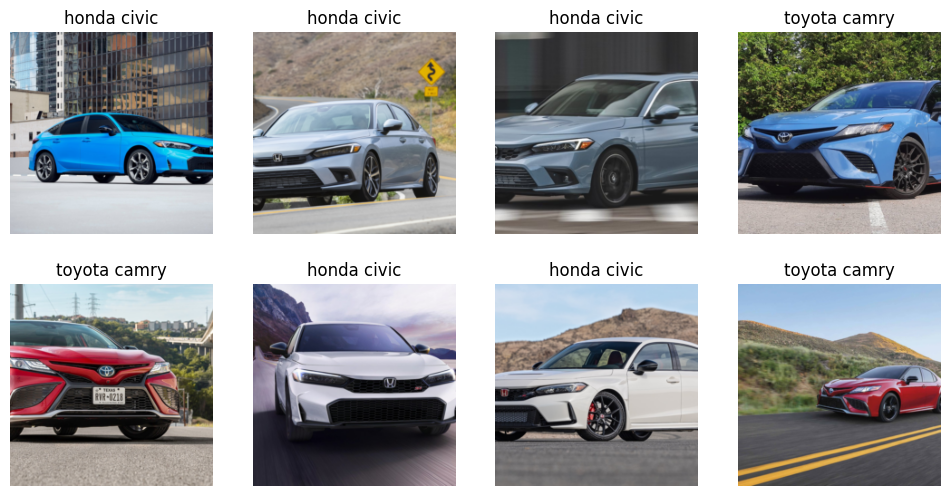

In [46]:
dls.show_batch(max_n=9)

<div></div>

d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: 

SuggestedLRs(valley=0.0010000000474974513)

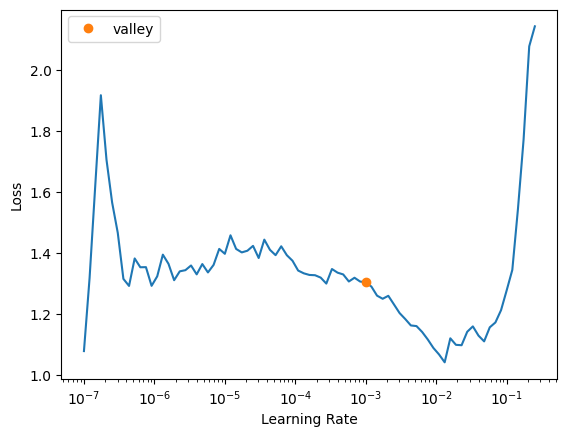

In [49]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.lr_find()

In [50]:
learn.fine_tune(4, base_lr=1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.140254,0.556945,0.269231,00:07


d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,1.055242,0.559421,0.230769,00:08
1,0.704844,0.465372,0.192308,00:09
2,0.549953,0.409043,0.153846,00:09
3,0.449730,0.411553,0.153846,00:09


d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\Projects\ml-learning\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: 

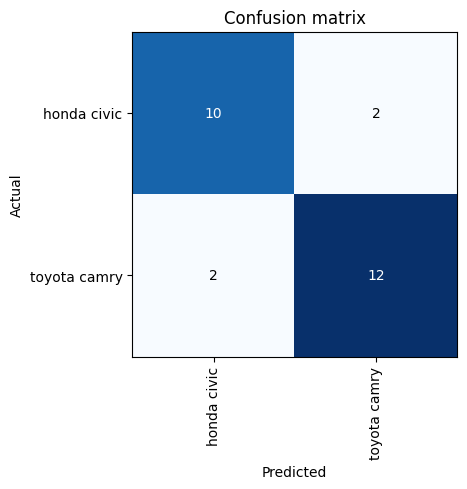

In [51]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

In [55]:
learn.predict(path/'toyota camry/toyota camry.webp')
learn.predict(path/'honda civic/honda civic.jpg')


('honda civic', tensor(0), tensor([0.6577, 0.3423]))

In [42]:
print(len(get_image_files(path/'honda civic')))
print(len(get_image_files(path/'toyota camry')))

38
71
